# Task 1 : Train an MLP to approximate y = sin(x)

In [2]:
import torch
import torch.nn as nn
import torch.optim
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from pysr import PySRRegressor


/home/boj4ck/Bureau/neuro_symbolic/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


In [3]:
class MLP(nn.Module):
    def __init__(self, n_inputs=1): # n_inputs=2 for a target like sin(x1) + x2**2
        super().__init__()
        # 3 NN layers can't have 1 otherwise output like(1,1) at least 2 conventional for this task 3
        # The performance of the model is more likely related to the nbr of layers more than the neurons.
        self.l1 = nn.Linear(n_inputs,64) # 1st layer: n_inputs value as input -> 64 values (64 neurons -> 1 value per neurons)
        self.l2 = nn.Linear(64,64) # 2nd layer: take those 64 values and pass them trough 2 layer producing another 64 values
        self.l3 = nn.Linear(64,1) # 3th layer: take those 64 values and return a single value as an output (the prediction)

    # forward function used for the forward pass
    def forward(self,x):
        # 2 first layer pass, must pass trough Relu activation function to break linearity on 0 Relu: R -> [0,+inf[
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x = self.l3(x) # we don't normalize the last output this is prediction
        return x


## Reusable functions

Each experiment below is described by its arguments : how many points, how much noise,
which operators, how many epochs. The model is always passed as a parameter.


In [ ]:
# ---- data

def make_training_data(n=100, noise=0.0, lo=-torch.pi, hi=torch.pi, seed=0):
    torch.manual_seed(seed)
    x = torch.rand(n,1) * (hi - lo) + lo
    return x, torch.sin(x) + noise * torch.randn_like(x) # noise = 0 -> clean sin(x)


def make_eval_grid(span=1.0, n=500):
    # n points on [-span*pi, span*pi]. n even means x = 0 is never sampled (0/0 expressions)
    return torch.linspace(-span * torch.pi, span * torch.pi, n).unsqueeze(1)


# ---- models

def make_mlp(lr=0.001, n_inputs=1):
    mlp = MLP(n_inputs)
    # the optimizer is built here with the model, so they always point to the same weights
    optimizer = torch.optim.SGD(mlp.parameters(), lr=lr, momentum=0.9)
    return mlp, optimizer


def make_sr(unary=('sin','cos','exp','log'), maxsize=30):
    return PySRRegressor(binary_operators=['+','-','*','/'],
                         unary_operators=list(unary), maxsize=maxsize)


# ---- training

def mlp_training(mlp, optimizer, x, y, epochs, log_every=1000):
    loss_fn = nn.MSELoss() # mean square loss function, this loss is usefull when we introduce noise

    for i in range(epochs):
        optimizer.zero_grad() # Reset grad at each epoch

        loss = loss_fn(mlp(x),y) # Compute loss
        loss.backward() # backprop

        optimizer.step()

        if i % log_every == 0:
            print(f'epoch: {i}, loss: {loss.item()}')
    print(f'epoch: {epochs}, loss: {loss.item()} (final)')
    return loss.item()


# ---- testing

def mlp_testing_phase(mlp, x_test, target=torch.sin, target_label='sin(x)', ylim=None):
    with torch.no_grad(): # don't generate the operations graph of the mlp
        y_pred = mlp(x_test)

    plt.plot(x_test, target(x_test), label=target_label) # target is a function, called on the grid
    plt.plot(x_test, y_pred, label="MLP")
    if ylim: # ylim=None -> matplotlib autoscales
        plt.ylim(*ylim)
    plt.legend()


def sr_testing_phase(model, x_test, target=torch.sin, label='sin(x)', ylim=None):
    print(f"chosen expression: {model.sympy()}\n")

    y_pred = model.predict(x_test)

    plt.plot(x_test, target(x_test), label=label) # target is a function ; label= else plt reads it as a format string
    plt.plot(x_test, y_pred, '--', label="symbolic regression")
    if ylim: # a diverging model autoscales the axis to 1e9 and flattens the target onto y=0.
        plt.ylim(*ylim) # ylim=None when the target itself is big, like exp(-x/3)*sin(3x)
    plt.legend()


In [ ]:
# Training phase
# task 3 will restrict the domain to [-pi, pi], so here we train on a wider one
x_train, y_train = make_training_data(n=1000, lo=-3*torch.pi, hi=3*torch.pi, seed=0)

mlp, optimizer = make_mlp()
mlp_training(mlp, optimizer, x_train, y_train, epochs=5000)


In [ ]:
# Testing phase
mlp_testing_phase(mlp, make_eval_grid(span=1))


# Task 2 : Use symbolic regression to recover sin(x)

## Symbolic regression model 1 configuration 
We define a first Symbolic regression model, this one will have those binary operator : ['+','-','*','/'] , and thos unary_operator: ['cos','sin','exp','log'] 

We generate 10 values of x in the interval [-pi;pi]


In [ ]:
# Defining
model_1 = make_sr(unary=('cos','sin','exp','log'))

# Training
x_sr, y_sr = make_training_data(n=10, seed=0)
model_1.fit(x_sr, y_sr)


# Evaluating symbolic regression model extrapolation

we test the model on a bigger interval than the one of it's training phase ([-7pi;7pi])

the model found x0*x0*sin(x0)/(x0*x0), which is exactly sin(x0) except in x=0 (0/0 -> NaN).
so extrapolation is perfect by construction, it's not a guess. the search just wasn't
parcimonious : the padding costs nothing in loss so it stays.


In [ ]:
# Testing phase
sr_testing_phase(model_1, make_eval_grid(span=7))


The model predict sin(x) perfectly.


## We can limit the max size of the output expression to avoid those monster of expression we had.
same data as model 1, only maxsize changes.


In [ ]:
model_2 = make_sr(maxsize=7) # 7 is the minimum accepted by PySR

x_sr_2, y_sr_2 = make_training_data(n=10, seed=0) # same data as model 1
model_2.fit(x_sr_2, y_sr_2)


In [ ]:
# Testing phase
sr_testing_phase(model_2, make_eval_grid(span=7))


## With a fixed maxsize of the output expression we get sin(x) instead of a monster expression


# Task 3 : Train the MLP only on [-pi, pi] and evaluate extrapolation

In [ ]:
# Training phase, this time only on [-pi, pi]
x_domain, y_domain = make_training_data(n=1000, seed=0)

mlp_domain, optimizer_domain = make_mlp()
mlp_training(mlp_domain, optimizer_domain, x_domain, y_domain, epochs=5000)


In [ ]:
# Testing phase, on a much bigger interval than the training one
mlp_testing_phase(mlp_domain, make_eval_grid(span=7))


# Task 4 : Compare MLP extrapolation with symbolic-regression extrapolation

# Experiment:  evalute the capacity of a model to predict sin(x) only with binary operators

We remove unary expression to do so, we set a high maxsize to allow the model to have a large expression 

The goal is to compare extrapolation with the MLP of task 1 : does symbolic regression go
further than the training domain, where the MLP stops right at the border ?


In [81]:
model_3 = make_sr(unary=(), maxsize=40) # no unary operator. above 40 PySR warns : exponentially slower

x_3, y_3 = make_training_data(n=100, seed=0)
model_3.fit(x_3, y_3)


[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.354e-01  0.000e+00  y = 0.0038487
3           2.033e-01  4.843e-01  y = x₀ * 0.31279
5           2.026e-01  1.747e-03  y = (x₀ * 0.31334) - -0.026651
7           9.998e-02  3.530e-01  y = x₀ / ((x₀ * x₀) + 0.44778)
9           4.412e-03  1.560e+00  y = x₀ * ((x₀ * (x₀ * -0.092441)) + 0.85178)
11          4.336e-03  8.654e-03  y = (x₀ - -0.01451) * (((x₀ * -0.09239) * x₀) + 0.85147)
13          4.258e-03  9.049e-03  y = (((x₀ * ((x₀ * -0.092474) + -0.0041025)) + 0.85154) * ...
                                      x₀) + 0.017796
15          2.023e-05  2.675e+00  y = (((((x₀ * (x₀ * 0.0056138)) + -0.15493) * x₀) * x₀) + ...
                                      0.98678) * x₀
17          1.946e-05  1.919e-02  y = x₀ * (((x₀ + -0.0016968) * (x₀ * (((x₀ * 0.0056183) * ...
                                      x₀) + -0.15497))) + 0.98688

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                        0.003848734   
	1         0.484263                                    x0 * 0.31278744   
	2         0.001747                   (x0 * 0.31334066) - -0.026650907   
	3         0.353016                      x0 / ((x0 * x0) + 0.44778368)   
	4         1.560366       x0 * ((x0 * (x0 * -0.09244121)) + 0.8517802)   
	5         0.008654  (x0 - -0.014509871) * (((x0 * -0.09239014) * x...   
	6         0.009049  (((x0 * ((x0 * -0.09247359) + -0.004102544)) +...   
	7         2.674815  (((((x0 * (x0 * 0.0056138015)) + -0.15492563) ...   
	8         0.019192  x0 * (((x0 + -0.0016968197) * (x0 * (((x0 * 0....   
	9         0.001485  (x0 + 0.00042169512) * ((((((x0 * (x0 * 0.0056...   
	10        3.278197  (0.9993784 - ((x0 * x0) * (0.165784 - ((0.0079...   
	11        0.000072  x0 * (0.99938357 - (x0 * ((x0 * (-0.077349074 ...   
	12      

We trained on [-pi; pi] and evaluate extrapolation on [-7pi; 7pi].

chosen expression: x0*(0.9998994 - (-2.1433392)*x0*x0*(-x0*x0*(-x0*x0*(-(-9.075514e-7)*x0*x0 - 8.777068e-5) - 0.003860757) - 0.077695206))



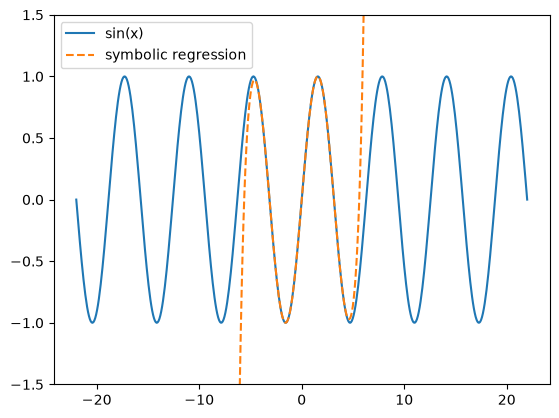

In [82]:
# Testing phase
sr_testing_phase(model_3, make_eval_grid(span=7))


symbolic regression extrapolates further than the MLP. it doesn't stop at the border of the
training domain ([-pi;pi]), it stays on sin until around 1.3 pi before breaking.
the MLP of task 1 breaks at 1.01 pi : relu makes it affine by pieces, so past the last
breakpoint it just continues as a straight line, no margin at all.

but it doesn't hold far away. without unary operators the model only builds rational
functions, and the expression found expands to a polynomial : it can't be periodic, it
diverges. what it found is the taylor serie of sin (x - x^3/6 + x^5/120), which is a local
approximation, good around 0 and divergent outside.

so the two models fail differently : the MLP degrades slowly (linear), symbolic regression
keeps sin longer but then explodes (1e8 at x=7pi).


In [80]:
# the expression is a polynomial : that is why it cannot stay periodic
x0 = sp.Symbol('x0')
expanded = sp.expand(model_3.sympy())
print(sp.Poly(expanded, x0).degree(), "degree polynomial")
print("taylor of sin to order 7 :", sp.series(sp.sin(x0), x0, 0, 7).removeO())

f = sp.lambdify(x0, expanded, 'numpy')
for xi in [3.0, 4.0, 6.0, 22.0]:
    print(f"x={xi:5.1f}  model={f(xi): .2e}   sin={np.sin(xi): .3f}")


11 degree polynomial
taylor of sin to order 7 : x0**5/120 - x0**3/6 + x0
x=  3.0  model= 1.41e-01   sin= 0.141
x=  4.0  model=-7.55e-01   sin=-0.757
x=  6.0  model= 3.33e-01   sin=-0.279
x= 22.0  model=-4.66e+06   sin=-0.009


# TASK 5: repeat with noisy data

we will add a bit of noise and see if the model is overfitting

In [75]:
# a fresh MLP, so this is a repeat of the experiment and not a continuation of the previous one
x_noise, y_noise = make_training_data(n=100, noise=0.1, seed=0)

mlp_noise, optimizer_noise = make_mlp()
mlp_training(mlp_noise, optimizer_noise, x_noise, y_noise, epochs=10000)


epoch: 0, loss: 0.8175362944602966
epoch: 1000, loss: 0.013028829358518124
epoch: 2000, loss: 0.008546793833374977
epoch: 3000, loss: 0.007872671820223331
epoch: 4000, loss: 0.007592733018100262
epoch: 5000, loss: 0.007452966645359993
epoch: 6000, loss: 0.0073834750801324844
epoch: 7000, loss: 0.007311216555535793
epoch: 8000, loss: 0.0072754304856061935
epoch: 9000, loss: 0.007250760681927204
epoch: 10000, loss: 0.007231228519231081 (final)


0.007231228519231081

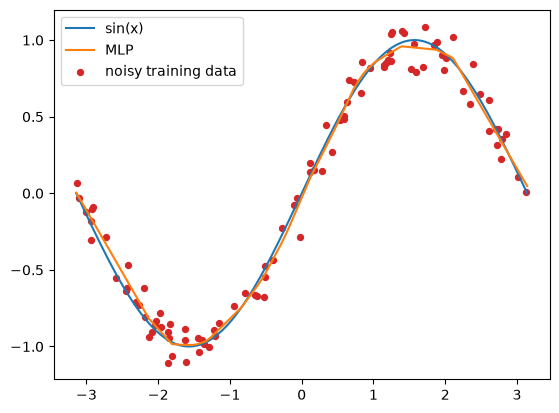

In [76]:
# Testing phase
mlp_testing_phase(mlp_noise, make_eval_grid(span=1))
plt.scatter(x_noise, y_noise, s=18, color='tab:red', label="noisy training data")
plt.legend()


In [77]:
# Does the prediction follow sin(x), or the noise ?
with torch.no_grad():
    y_on_train = mlp_noise(x_noise)

# sin(x) itself scores this MSE on the noisy targets : nothing can do better honestly
floor = ((y_noise - torch.sin(x_noise)) ** 2).mean()

print(f"noise floor                   : {floor:.3e}")
print(f"MSE against the noisy targets : {((y_on_train - y_noise) ** 2).mean():.3e}   <- below the floor = memorised")
print(f"MSE against the clean sin(x)  : {((y_on_train - torch.sin(x_noise)) ** 2).mean():.3e}")


noise floor                   : 8.316e-03
MSE against the noisy targets : 7.231e-03   <- below the floor = memorised
MSE against the clean sin(x)  : 1.051e-03


after running multiples of time the training, we see the loss going down still, somehow we can see that the prediction on sin is slitly different, that confirm that the model "thinks" that the prediction it's close enough, but he is learning the noise he dosen't differentiate sin(x) of the noise

In [78]:
# same noisy data, this time for the symbolic regression
model_noise = make_sr()
model_noise.fit(x_noise, y_noise)


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.197e-01  0.000e+00  y = 0.0035663
2           8.316e-03  4.135e+00  y = sin(x₀)
4           8.046e-03  1.648e-02  y = sin(x₀) * 0.97757
6           7.782e-03  1.669e-02  y = sin(x₀ + (0.0047629 / x₀))
7           7.634e-03  1.924e-02  y = sin(x₀ / cos(-0.035027 / x₀))
8           7.275e-03  4.806e-02  y = sin(x₀ / ((0.021241 / x₀) + 0.98803))
10          7.189e-03  6.007e-03  y = sin(x₀ / ((0.020891 / x₀) + 0.98803)) * 0.98803
12          7.080e-03  7.617e-03  y = sin(x₀ / cos((-0.035106 / x₀) / cos(x₀ / 0.98831)))
14          6.810e-03  1.942e-02  y = sin((x₀ / 0.98831) / cos((-0.03505 / x₀) / cos(x₀ / 0....
                                      98831)))
16          6.729e-03  5.965e-03  y = sin((x₀ / cos((-0.035106 / x₀) / cos(x₀ / 0.98831))) /...
                                       0.98991) * 0.98831
20          6.729e-03  9.

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                       0.0035663089   
	1   >>>>  4.135111                                            sin(x0)   
	2         0.016483                                sin(x0) * 0.9775702   
	3         0.016691                      sin(x0 + (0.0047629303 / x0))   
	4         0.019243                   sin(x0 / cos(-0.035027344 / x0))   
	5         0.048059        sin(x0 / ((0.021241192 / x0) + 0.98802805))   
	6         0.006007  sin(x0 / ((0.020891065 / x0) + 0.98802805)) * ...   
	7         0.007617  sin(x0 / cos((-0.03510577 / x0) / cos(x0 / 0.9...   
	8         0.019417  sin((x0 / 0.9883086) / cos((-0.035050176 / x0)...   
	9         0.005965  sin((x0 / cos((-0.03510577 / x0) / cos(x0 / 0....   
	10        0.000009  sin((x0 / cos((((-0.035002332 / cos(x0 / 0.988...   
	11        0.005425  sin((x0 / cos(((-0.03486297 / x0) / cos(x0 / 0...   
	12      

chosen expression: sin(x0)

noise floor                   : 8.316e-03
MSE against the noisy targets : 8.316e-03   <- equal to the floor = nothing memorised


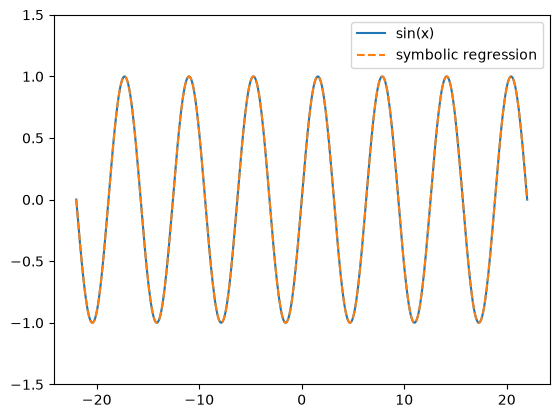

In [79]:
# Testing phase
sr_testing_phase(model_noise, make_eval_grid(span=7))

y_sr_pred = torch.as_tensor(model_noise.predict(x_noise)).reshape(-1,1)
floor = ((y_noise - torch.sin(x_noise)) ** 2).mean()
print(f"noise floor                   : {floor:.3e}")
print(f"MSE against the noisy targets : {((y_sr_pred - y_noise) ** 2).mean():.3e}   <- equal to the floor = nothing memorised")


For the symbolic regression, the noise dosen't affect the prediction, the expressions chosen is still sin(x) so the model predict correctly.

# Task 6: Repeat with harder target functions (beyond sin)

## 1st harder target: exp(-x/3) * sin(3x)

we add little bit of spice with 2 2 unary operator to evaluate the capacity of sr to recover (we will try it both on the mlp and the sr and evaluate extrapolation as well)

In [6]:
def target_1(x): # a target harder to recover than sin(x)
    return torch.exp(-x/3) * torch.sin(3*x)

def target_2(x1,x2):
    return torch.sin(x1) + x2 **2

In [11]:
def mlp_testing_phase_2d(mlp, target, span=1, n=200):
    # one regular axis, shared by x1 and x2, on [-span*pi, span*pi]
    axis = torch.linspace(-span*torch.pi, span*torch.pi, n)
    x1, x2 = torch.meshgrid(axis, axis, indexing='xy') # two (n,n) grids covering the square

    # the network wants a (points, 2) table : flatten each grid and cat the two columns
    grid = torch.cat([x1.reshape(-1,1), x2.reshape(-1,1)], dim=1)
    with torch.no_grad():
        y_pred = mlp(grid).reshape(n, n) # back to the grid shape
    error = (y_pred - target(x1, x2)).abs() # the color is the error, not the value

    plt.pcolormesh(x1, x2, error, shading='auto')
    plt.colorbar(label="|MLP - target|")
    plt.xlabel("x1"); plt.ylabel("x2")


In [22]:
def sr_testing_phase_2d(model, target, span=1, n=200):
    print(f"chosen expression: {model.sympy()}\n")
    # one regular axis, shared by x1 and x2, on [-span*pi, span*pi]
    axis = torch.linspace(-span*torch.pi, span*torch.pi, n)
    x1, x2 = torch.meshgrid(axis, axis, indexing='xy') # two (n,n) grids covering the square

    grid = torch.cat([x1.reshape(-1,1), x2.reshape(-1,1)], dim=1) # predict wants a (points, 2) table
    y_pred = torch.as_tensor(model.predict(grid)).reshape(n, n) # predict returns numpy, back to grid shape
    error = (y_pred - target(x1, x2)).abs() # the color is the error, not the value

    plt.pcolormesh(x1, x2, error, shading='auto')
    plt.colorbar(label="|SR - target|")
    plt.xlabel("x1"); plt.ylabel("x2")


In [97]:

x_c1 = torch.rand(100,1) * 2 * torch.pi - torch.pi
y_c1 = target_1(x_c1)

mlp_c1,opt_c1 = make_mlp()
sr_c1 = make_sr()

In [117]:
mlp_training(mlp_c1,opt_c1,x_c1,y_c1,100000)

epoch: 0, loss: 0.0005146907060407102
epoch: 1000, loss: 0.0005125805619172752
epoch: 2000, loss: 0.0005105974851176143
epoch: 3000, loss: 0.0005087629542686045
epoch: 4000, loss: 0.0005070933257229626
epoch: 5000, loss: 0.0005055266665294766
epoch: 6000, loss: 0.0005040729884058237
epoch: 7000, loss: 0.0005027081933803856
epoch: 8000, loss: 0.0005014566122554243
epoch: 9000, loss: 0.0005003057303838432
epoch: 10000, loss: 0.0004992256872355938
epoch: 11000, loss: 0.000498209847137332
epoch: 12000, loss: 0.0004972707247361541
epoch: 13000, loss: 0.0004964034887962043
epoch: 14000, loss: 0.0004956020275130868
epoch: 15000, loss: 0.0004948615096509457
epoch: 16000, loss: 0.000494151609018445
epoch: 17000, loss: 0.0004935153410769999
epoch: 18000, loss: 0.0004928985144942999
epoch: 19000, loss: 0.0004923281958326697
epoch: 20000, loss: 0.0004918075865134597
epoch: 21000, loss: 0.0004913245793431997
epoch: 22000, loss: 0.0004908745177090168
epoch: 23000, loss: 0.0004904560628347099
epoch: 

0.00036456563975661993

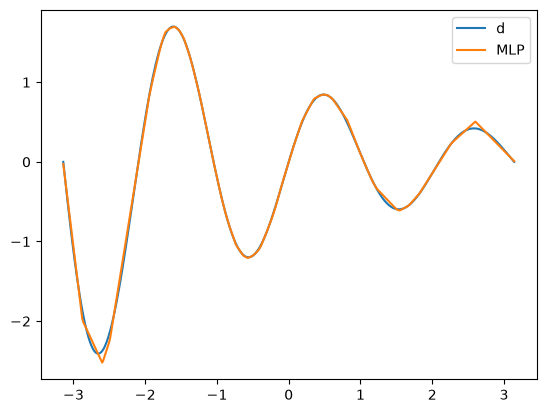

In [121]:
x_test_c1 = make_eval_grid(span=1)
mlp_testing_phase(mlp_c1, x_test_c1, target_1, 'exp(-x/3)*sin(3x)')

In [122]:
sr_c1.fit(x_c1,y_c1)

[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.008e+00  0.000e+00  y = -0.078641
2           1.008e+00  2.271e-05  y = cos(x₀)
3           9.235e-01  8.780e-02  y = x₀ * 0.16963
4           2.557e-01  1.284e+00  y = sin(x₀ * 2.9742)
6           2.173e-01  8.139e-02  y = sin(x₀ * 2.9812) * 1.2819
8           2.001e-01  4.112e-02  y = (sin(x₀ * 2.9895) * 1.2943) + -0.1321
9           4.499e-13  2.682e+01  y = sin(x₀ * 3) * exp(x₀ * -0.33333)
11          2.284e-15  2.642e+00  y = sin(x₀ + (x₀ + x₀)) * exp(x₀ * -0.33333)
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs/20260930_233422_ToU9OS/hall_of_fame.csv


[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick      score                                         equation  \
	0         0.000000                                      -0.07864148   
	1         0.000023                                          cos(x0)   
	2         0.087800                                    x0 * 0.169633   
	3         1.284052                              sin(x0 * 2.9742181)   
	4         0.081386                  sin(x0 * 2.9812362) * 1.2818687   
	5         0.041117  (sin(x0 * 2.9895449) * 1.2943323) + -0.13209711   
	6        26.820998      sin(x0 * 2.9999998) * exp(x0 * -0.33333334)   
	7  >>>>   2.641517      sin(x0 + (x0 + x0)) * exp(x0 * -0.33333334)   
	
	           loss  complexity  
	0  1.008224e+00           1  
	1  1.008201e+00           2  
	2  9.234557e-01           3  
	3  2.557169e-01           4  
	4  2.173043e-01           6  
	5  2.001494e-01           8  
	6  4.499276e-13           9  
	7  2.284284e-15          11  
]

chosen expression: exp(x0*(-0.33333334))*sin(x0 + x0 + x0)



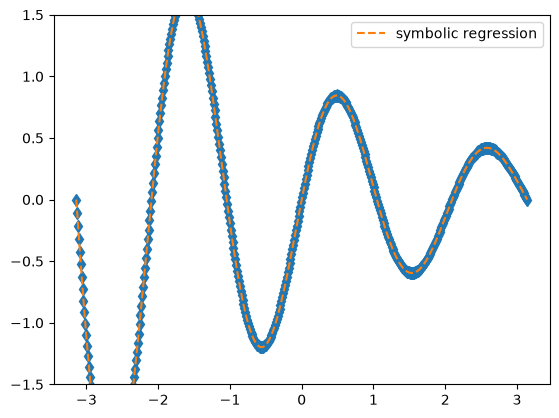

In [126]:

sr_testing_phase(sr_c1, x_test_c1, target_1, 'exp(-x/3)*sin(3x)')

chosen expression: exp(x0*(-0.33333334))*sin(x0 + x0 + x0)



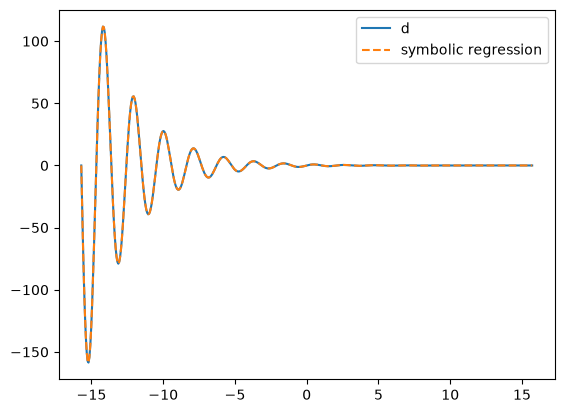

In [130]:
x_test_c1_extra = make_eval_grid(5)

sr_testing_phase(sr_c1, x_test_c1_extra, target_1, 'exp(-x/3)*sin(3x)')

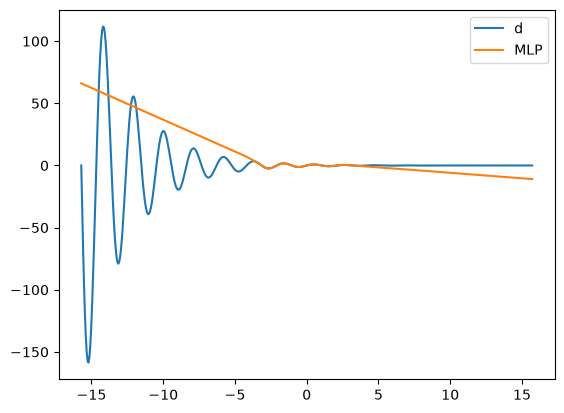

In [131]:
mlp_testing_phase(mlp_c1, x_test_c1_extra, target_1, 'exp(-x/3)*sin(3x)')

# Conclusion for the first harder target:

- MLP is fine inside the training domain : R2 = 0.9996, typical error 0.019 on a
  function going from -2.41 to 1.70
- SR recovered the target exactly, with both constants :
  exp(x0*(-0.33333334)) * sin(x0 + x0 + x0), where x0+x0+x0 = 3x0 and -0.33333334
  is -1/3 in float32. max gap with the target on [-5pi, 5pi] : 1.6e-05, only the
  float rounding
- on extrapolation SR is perfect because the expression IS the target, there is
  nothing left to extrapolate. same argument as task 2
- the MLP goes out as a straight line, from +65 on the left to -12 on the right,
  while the target oscillates at +/-160 then dies out. it fails on both sides for
  opposite reasons : a line can't grow exponentially on the left, and it can't
  settle on zero on the right

compared to task 4 this is the same algorithm, the same protocol and the same
training domain, but the opposite result : there the SR only had binary operators
and ended on a diverging polynomial, here exp and sin were available and it
recovered the formula. the only thing that changed is the operator set, so what
limited the SR in task 4 was expressiveness, not the search.

the other way around, a target outside of the operator set (tanh for example)
would fail exactly like task 4. SR is exact when the target is inside its search
space, not in general.

In [ ]:
x1_c2 = torch.rand(100, 1) * 2 * torch.pi - torch.pi
x2_c2 = torch.rand(100, 1) * 2 * torch.pi - torch.pi
y_c2 = target_2(x1_c2,x2_c2)

x_c2 = torch.cat([x1_c2, x2_c2], dim=1)
mlp_c2, opt_c2 = make_mlp(n_inputs=2)
mlp_training(mlp_c2,opt_c2,x_c2,y_c2,5000)

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

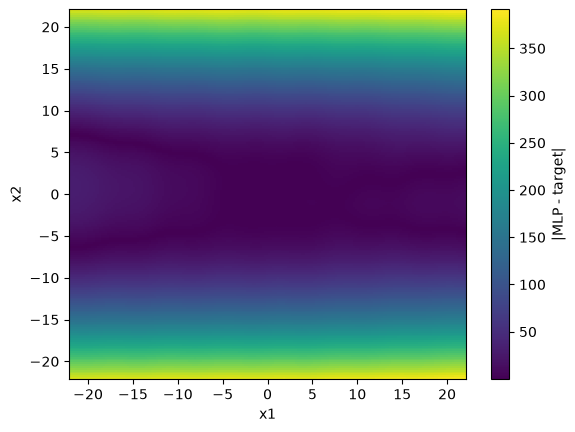

In [15]:
mlp_testing_phase_2d(mlp_c2,target=target_2,span=7)

In [24]:
sr_c2 = make_sr()
sr_c2.fit(x_c2,y_c2)

[ Info: Started!



Expressions evaluated per second: 4.960e+05
Progress: 77 / 100 total iterations (77.484%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.706e+00  0.000e+00  y = 3.4009
3           5.311e-01  1.337e+00  y = x₁ * x₁
5           5.028e-01  2.731e-02  y = (x₁ * x₁) / 1.0388
6           2.274e-15  3.303e+01  y = sin(x₀) + (x₁ * x₁)
13          0.000e+00  1.475e+01  y = (((x₁ * 8.6036e-10) * exp(x₁)) + sin(x₀)) + (x₁ * x₁)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════


[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.706e+00  0.000e+00  y = 3.4009
3           5.311e-01  1.337e+00  y = x₁ * x₁
5           5.028e-01  2.731e-02  y = (x₁ * x₁) / 1.0388
6           2.274e-15  3.303e+01  y = sin(x₀) + (x₁ * x₁)
11          5.551e-19  1.664e+00  y = (x₁ * x₁) + ((exp(x₁) * 2.252e-09) + sin(x₀))
13          0.000e+00  5.164e+01  y = (((x₁ * 8.6036e-10) * exp(x₁)) + sin(x₀)) + (x₁ * x₁)
─────────────────────────────────────────────────────────────────────────────────��─────────────────
  - outputs/20261001_172718_Gk6P3L/hall_of_fame.csv


PySRRegressor.equations_ = [
	   pick      score                                           equation  \
	0         0.000000                                          3.4009495   
	1         1.337441                                            x1 * x1   
	2         0.027309                              (x1 * x1) / 1.0387721   
	3        33.029866                                sin(x0) + (x1 * x1)   
	4         1.663553   (x1 * x1) + ((exp(x1) * 2.2520084e-9) + sin(x0))   
	5  >>>>        inf  (((x1 * 8.6036395e-10) * exp(x1)) + sin(x0)) +...   
	
	           loss  complexity  
	0  7.706122e+00           1  
	1  5.310667e-01           3  
	2  5.028388e-01           5  
	3  2.273737e-15           6  
	4  5.551115e-19          11  
	5  0.000000e+00          13  
]

chosen expression: x1*8.6036395e-10*exp(x1) + x1*x1 + sin(x0)



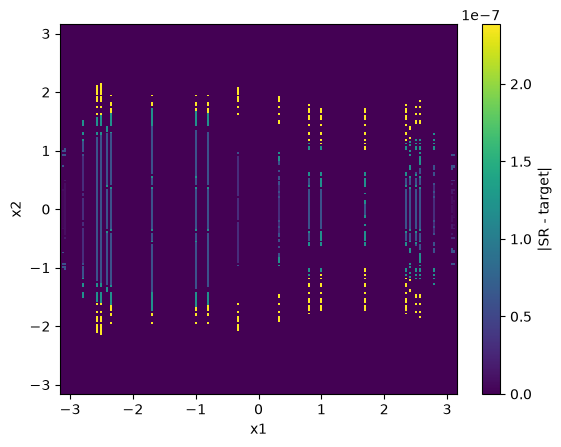

In [25]:
sr_testing_phase_2d(sr_c2,target_2)